In [1]:
import os
import re
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from matplotlib import rcParams
import matplotlib.patches as patches
from scipy.optimize import curve_fit

#%matplotlib inline

# plot style
rcParams['mathtext.fontset'] = 'stix'
rcParams['font.family'] = 'STIXGeneral'
rcParams['figure.figsize'] = [16, 6]
rcParams['font.size'] = 22
rcParams['axes.labelsize'] = 20
rcParams['axes.titlesize'] = 20
rcParams['legend.fontsize'] = 16
rcParams['xtick.labelsize'] = 12
rcParams['ytick.labelsize'] = 16

from mpl_toolkits.mplot3d import Axes3D  

# to prevent ROOT errors
root_path = "/scratch/elena/root-6.26.04-install"
os.environ["ROOTSYS"] = root_path
os.environ["PYTHONPATH"] = f"{root_path}/lib:{os.environ.get('PYTHONPATH', '')}"
os.environ["LD_LIBRARY_PATH"] = f"{root_path}/lib:{os.environ.get('LD_LIBRARY_PATH', '')}"
sys.path.append(f"{root_path}/lib")

#set variables so functions_bonsai can locate required files
os.environ["WCSIM_BUILD_DIR"] = "/scratch/elena/wcsim-install"
os.environ["BONSAIDIR"] = "/scratch/elena/bonsai"


sys.path.append("/scratch/elena/9Li/scripts")
import functions_bonsai
import functions_multilateration

Welcome to JupyROOT 6.26/04


In [4]:
import os
import glob
import pandas as pd

# ----------------------------------------------------------------------
# CONFIGURATION & RUN MAPPING
# ----------------------------------------------------------------------
RUNS = [1846, 1848, 1928, 1930, 1932, 1934, 1935, 1936, 1937, 1938, 1939, 1941]
BASE_DIR = "/scratch/elena/9Li/results"

# Helper function to assign Beam Momentum based on your rules
def get_beam_momentum(run_id):
    if run_id in [1846, 1848]:
        return "-340 MeV/c"
    else:
        return "-260 MeV/c"

# Lists to collect our summary statistics
before_fv_summary = []
after_fv_summary = []

print("Gathering cluster statistics across runs...\n")

# ----------------------------------------------------------------------
# DATA LOADING & COUNTING
# ----------------------------------------------------------------------
for run in RUNS:
    run_folder = f"{BASE_DIR}/run{run}/processed"
    momentum = get_beam_momentum(run)
    
    # --- 1. Count BEFORE strict FV (Summing up the individual refined chunk files) ---
    refined_pattern = os.path.join(run_folder, "Refine_Li9_clusters_chunk*_BKG.pkl")
    refined_files = glob.glob(refined_pattern)
    
    total_before = 0
    for f in refined_files:
        try:
            df_chunk = pd.read_pickle(f)
            total_before += len(df_chunk)
        except Exception:
            pass # Handle empty or corrupted files safely
            
    before_fv_summary.append({
        "Run": f"Run {run}",
        "Beam Momentum": momentum,
        "Clusters (Before FV)": total_before
    })
    
    # --- 2. Count AFTER strict FV (Loading the single consolidated file) ---
    final_fv_file = os.path.join(run_folder, f"Final_FV_Li9_clusters_run{run}_BKG.pkl")
    
    total_after = 0
    if os.path.exists(final_fv_file):
        try:
            df_final = pd.read_pickle(final_fv_file)
            total_after = len(df_final)
        except Exception:
            pass
            
    after_fv_summary.append({
        "Run": f"Run {run}",
        "Beam Momentum": momentum,
        "Clusters (Within FV)": total_after
    })

# ----------------------------------------------------------------------
# CONVERT TO DATAFRAMES AND PRINT TABLES
# ----------------------------------------------------------------------
df_before = pd.DataFrame(before_fv_summary)
df_after = pd.DataFrame(after_fv_summary)

print("=" * 60)
print("TABLE 1: BACKGROUND CLUSTER CANDIDATES BEFORE FIDUCIAL VOLUME CUT")
print("=" * 60)
print(df_before.to_string(index=False))

print("\n" + "=" * 60)
print("TABLE 2: BACKGROUND FINAL CLUSTER CANDIDATES WITHIN THE FIDUCIAL VOLUME")
print("=" * 60)
print(df_after.to_string(index=False))

Gathering cluster statistics across runs...

TABLE 1: BACKGROUND CLUSTER CANDIDATES BEFORE FIDUCIAL VOLUME CUT
     Run Beam Momentum  Clusters (Before FV)
Run 1846    -340 MeV/c                 28760
Run 1848    -340 MeV/c                 25502
Run 1928    -260 MeV/c                 80308
Run 1930    -260 MeV/c                122329
Run 1932    -260 MeV/c                101171
Run 1934    -260 MeV/c                 70304
Run 1935    -260 MeV/c                 69064
Run 1936    -260 MeV/c                 54751
Run 1937    -260 MeV/c                 75091
Run 1938    -260 MeV/c                 44792
Run 1939    -260 MeV/c                 77072
Run 1941    -260 MeV/c                 94885

TABLE 2: BACKGROUND FINAL CLUSTER CANDIDATES WITHIN THE FIDUCIAL VOLUME
     Run Beam Momentum  Clusters (Within FV)
Run 1846    -340 MeV/c                   362
Run 1848    -340 MeV/c                   296
Run 1928    -260 MeV/c                   387
Run 1930    -260 MeV/c                   819
Run 19

In [6]:
import os
import glob
import pandas as pd

# ----------------------------------------------------------------------
# STRUCTURAL INSPECTION PIPELINE
# ----------------------------------------------------------------------
RUN_TEST = 1932
BASE_DIR = "/scratch/elena/9Li/results"
run_folder = f"{BASE_DIR}/run{RUN_TEST}/processed"

print("=" * 70)
print(f"DIAGNOSTIC PIPELINE: AUDITING COLUMN EVOLUTION FOR RUN {RUN_TEST}")
print("=" * 70)

# --- STAGE 1: Original Unrefined Chunks ---
original_pattern = os.path.join(run_folder, "Li9_clusters_range(15-50)_chunk*_BKG.pkl")
original_files = sorted(glob.glob(original_pattern))

if original_files:
    print(f"\n[STAGE 1] Found Original Chunk: {os.path.basename(original_files[0])}")
    try:
        df_orig = pd.read_pickle(original_files[0])
        print("Available columns:")
        print(sorted(list(df_orig.columns)))
    except Exception as e:
        print(f"Error reading Stage 1 file: {e}")
else:
    print("\n[STAGE 1] Warning: No original chunk files found to inspect.")

# --- STAGE 2: Refined Chunks ---
refined_pattern = os.path.join(run_folder, "Refine_Li9_clusters_chunk*_BKG.pkl")
refined_files = sorted(glob.glob(refined_pattern))

if refined_files:
    print(f"\n[STAGE 2] Found Refined Chunk: {os.path.basename(refined_files[0])}")
    try:
        df_ref = pd.read_pickle(refined_files[0])
        print("Available columns:")
        print(sorted(list(df_ref.columns)))
    except Exception as e:
        print(f"Error reading Stage 2 file: {e}")
else:
    print("\n[STAGE 2] Warning: No refined chunk files found to inspect.")

# --- STAGE 3: Final Consolidated FV File ---
final_fv_file = os.path.join(run_folder, f"Final_FV_Li9_clusters_run{RUN_TEST}_BKG.pkl")

if os.path.exists(final_fv_file):
    print(f"\n[STAGE 3] Found Final FV Merged File: {os.path.basename(final_fv_file)}")
    try:
        df_final = pd.read_pickle(final_fv_file)
        print("Available columns:")
        print(sorted(list(df_final.columns)))
    except Exception as e:
        print(f"Error reading Stage 3 file: {e}")
else:
    print(f"\n[STAGE 3] Warning: The final file '{os.path.basename(final_fv_file)}' does not exist.")

print("\n" + "=" * 70)
print("Please review the output tables above to locate your time series key.")
print("=" * 70)

DIAGNOSTIC PIPELINE: AUDITING COLUMN EVOLUTION FOR RUN 1932

[STAGE 1] Found Original Chunk: Li9_clusters_range(15-50)_chunk_0_BKG.pkl
Available columns:
['chi2', 'chi2_ndof', 'fit_success', 'hit_charges', 'hit_position_ids', 'hit_slot_ids', 'hit_times_ns', 'nCLusters_in_spill', 'nHits', 'n_hits_used', 'ndof', 'spill_id', 't_rms_ns', 't_window_start_ns', 't_window_start_rel_ns', 'time_rms', 'vertex_x', 'vertex_y', 'vertex_z']

[STAGE 2] Found Refined Chunk: Refine_Li9_clusters_chunk_0_BKG.pkl
Available columns:
['chi2', 'chi2_ndof', 'fit_success', 'hit_charges', 'hit_position_ids', 'hit_slot_ids', 'hit_times_ns', 'nCLusters_in_spill', 'nHits', 'n_hits_used', 'ndof', 'nhits_fine', 'spill_id', 't_rms_fine', 't_rms_ns', 't_window_start_ns', 't_window_start_rel_ns', 'time_rms', 'v_x_fine', 'v_y_fine', 'v_z_fine', 'vertex_x', 'vertex_y', 'vertex_z']

[STAGE 3] Found Final FV Merged File: Final_FV_Li9_clusters_run1932_BKG.pkl
Available columns:
['chi2', 'chi2_ndof', 'fit_success', 'hit_charg


Loading final data files and merging by momentum...


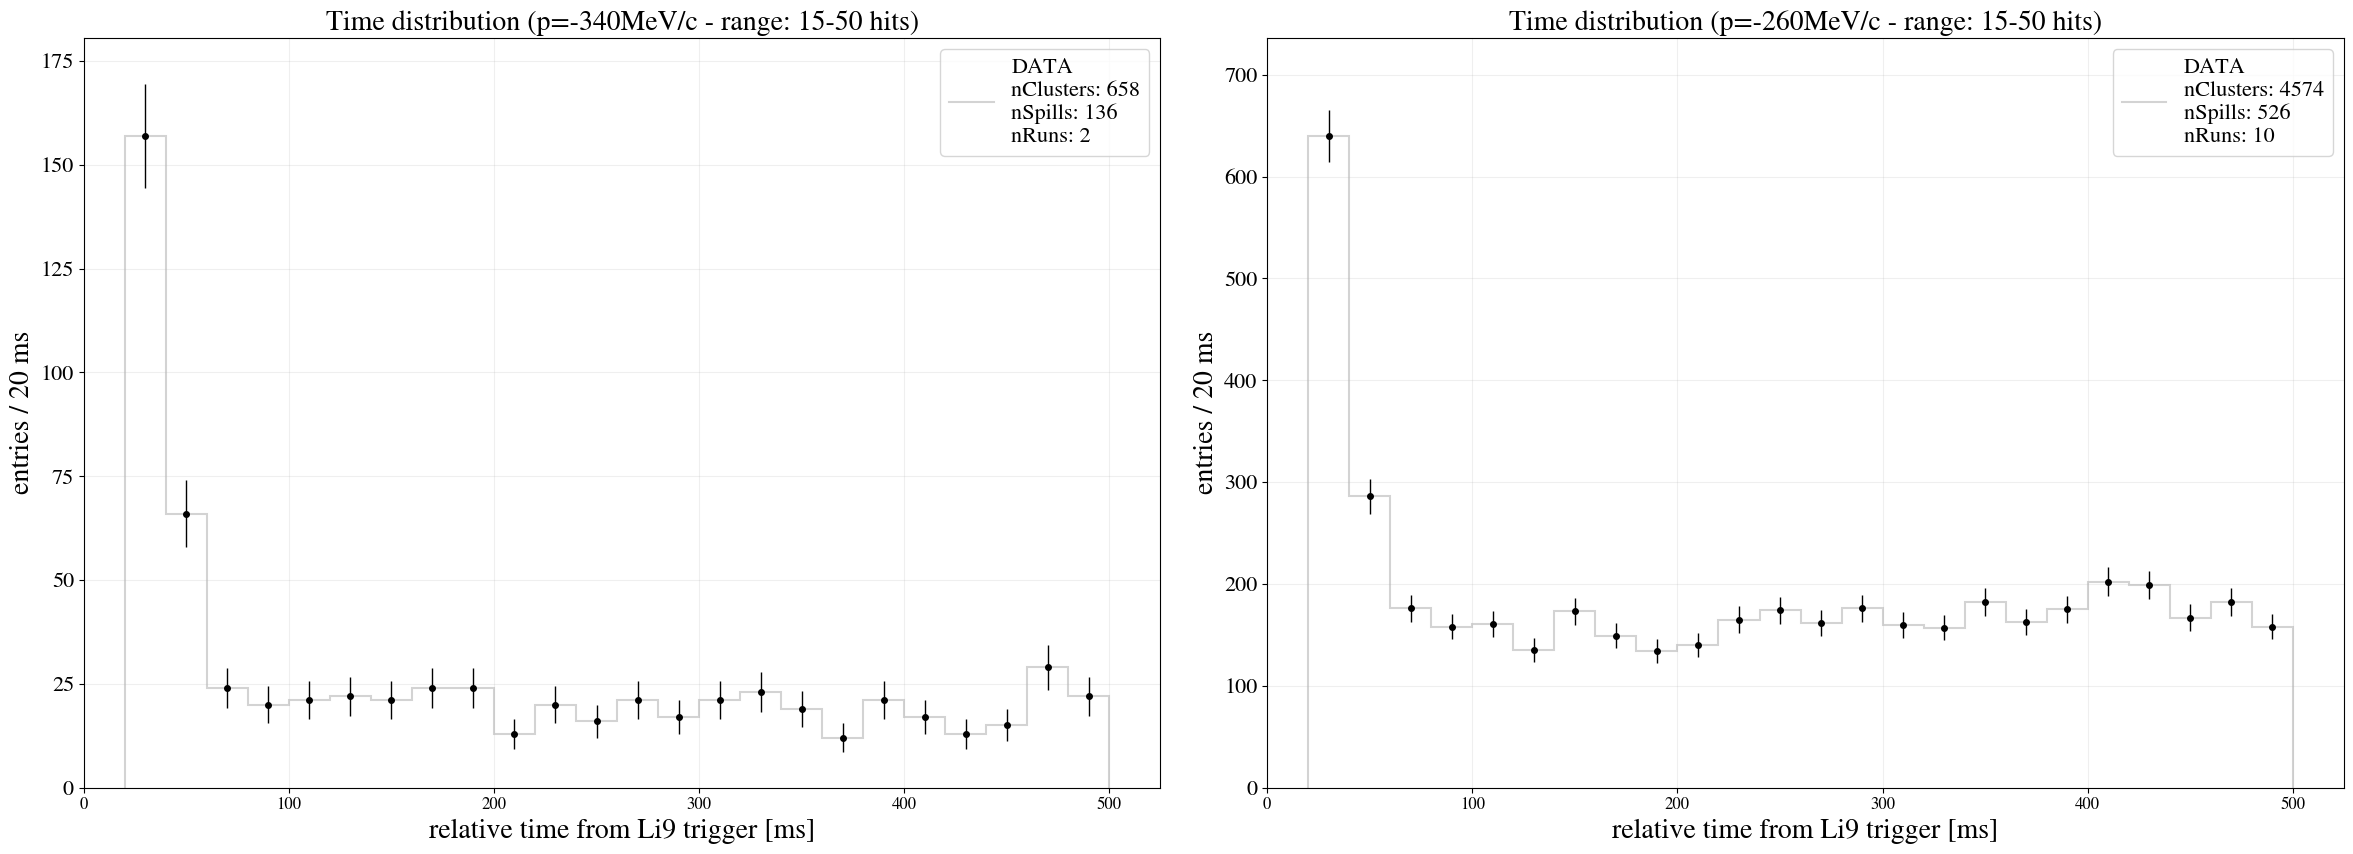

In [7]:
# ----------------------------------------------------------------------
# DATA LOADING & MERGING BY MOMENTUM
# ----------------------------------------------------------------------
momentum_map = {run: get_beam_momentum(run) for run in RUNS}

dfs_340 = []
dfs_260 = []

print("\nLoading final data files and merging by momentum...")

for run in RUNS:
    run_folder = f"{BASE_DIR}/run{run}/processed"
    final_fv_file = os.path.join(run_folder, f"Final_FV_Li9_clusters_run{run}_BKG.pkl")
    
    if os.path.exists(final_fv_file):
        try:
            df = pd.read_pickle(final_fv_file)
            if not df.empty:
                df['origin_run'] = run
                if momentum_map[run] == "-340 MeV/c":
                    dfs_340.append(df)
                else:
                    dfs_260.append(df)
        except Exception as e:
            print(f"Error loading {final_fv_file}: {e}")

df_340_combined = pd.concat(dfs_340, ignore_index=True) if dfs_340 else pd.DataFrame()
df_260_combined = pd.concat(dfs_260, ignore_index=True) if dfs_260 else pd.DataFrame()

# ----------------------------------------------------------------------
# HISTOGRAM & PLOTTING CONFIGURATION (FIXED FOR UNITS)
# ----------------------------------------------------------------------
rcParams['figure.figsize'] = [24, 9]
fig, axs = plt.subplots(1, 2, sharey=False)

bin_width = 20  # ms
bins = np.arange(20, 500 + bin_width, bin_width)
time_column = "t_window_start_rel_ns" 

plot_configs = [
    {
        "df": df_340_combined,
        "ax": axs[0],
        "title": "Time distribution (p=-340MeV/c - range: 15-50 hits)",
        "num_runs": len(dfs_340),
        #"const_line": 45.98  # Constant line value for 340 MeV/c
    },
    {
        "df": df_260_combined,
        "ax": axs[1],
        "title": "Time distribution (p=-260MeV/c - range: 15-50 hits)",
        "num_runs": len(dfs_260),
        #"const_line": 45.98  # Adjust this value if the 260 MeV/c background baseline differs
    }
]

for config in plot_configs:
    df_plot = config["df"]
    ax = config["ax"]
    
    if df_plot.empty:
        ax.text(0.5, 0.5, "No Data Within FV", transform=ax.transAxes, ha="center")
        ax.set_title(config["title"])
        continue

    if time_column not in df_plot.columns:
        print(f"Error: Column '{time_column}' not found.")
        continue

    # UNIT CONVERSION CRITICAL FIX: Convert 't_window_start_rel_ns' from ns to ms
    time_in_ms = df_plot[time_column] / 1e6

    # Apply the exact histogram logic with the 20 ms offset shift
    counts, bin_edges = np.histogram(time_in_ms + 20, bins=bins)
    
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    errors = np.sqrt(np.maximum(counts, 1))

    # Draw step histogram profile
    ax.stairs(
        counts,
        bin_edges,
        color="lightgray",
        linewidth=1.5,
        label=(
            f"DATA\n"
            f"nClusters: {len(df_plot)}\n"
            f"nSpills: {df_plot['spill_id'].nunique() if 'spill_id' in df_plot.columns else 'N/A'}\n"
            f"nRuns: {config['num_runs']}"
        ),
    )

    # Superimpose clean error data points
    ax.errorbar(bin_centers, counts, yerr=errors, fmt="o", color="black", markersize=4, capsize=0, elinewidth=1, ls="none")

    # Horizontal baseline restriction strictly bounded between 20 ms and 500 ms
    #ax.hlines(y=config["const_line"], xmin=20, xmax=500, color="red", linewidth=2.5, label=f"C = {config['const_line']}")

    # Set axes parameters, labels, and clean background grids
    ax.set_title(config["title"])
    ax.set_xlabel("relative time from Li9 trigger [ms]")
    ax.set_ylabel(f"entries / {bin_width} ms")
    ax.grid(True, which="both", linestyle="-", alpha=0.2)
    
    # Explicitly linear scale to match the aesthetic reference panel
    ax.set_yscale("linear")
    ax.set_xlim(0, 525)
    ax.set_ylim(0, max(counts) * 1.15)
    
    ax.legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.show()


Loading final data files and merging by momentum...


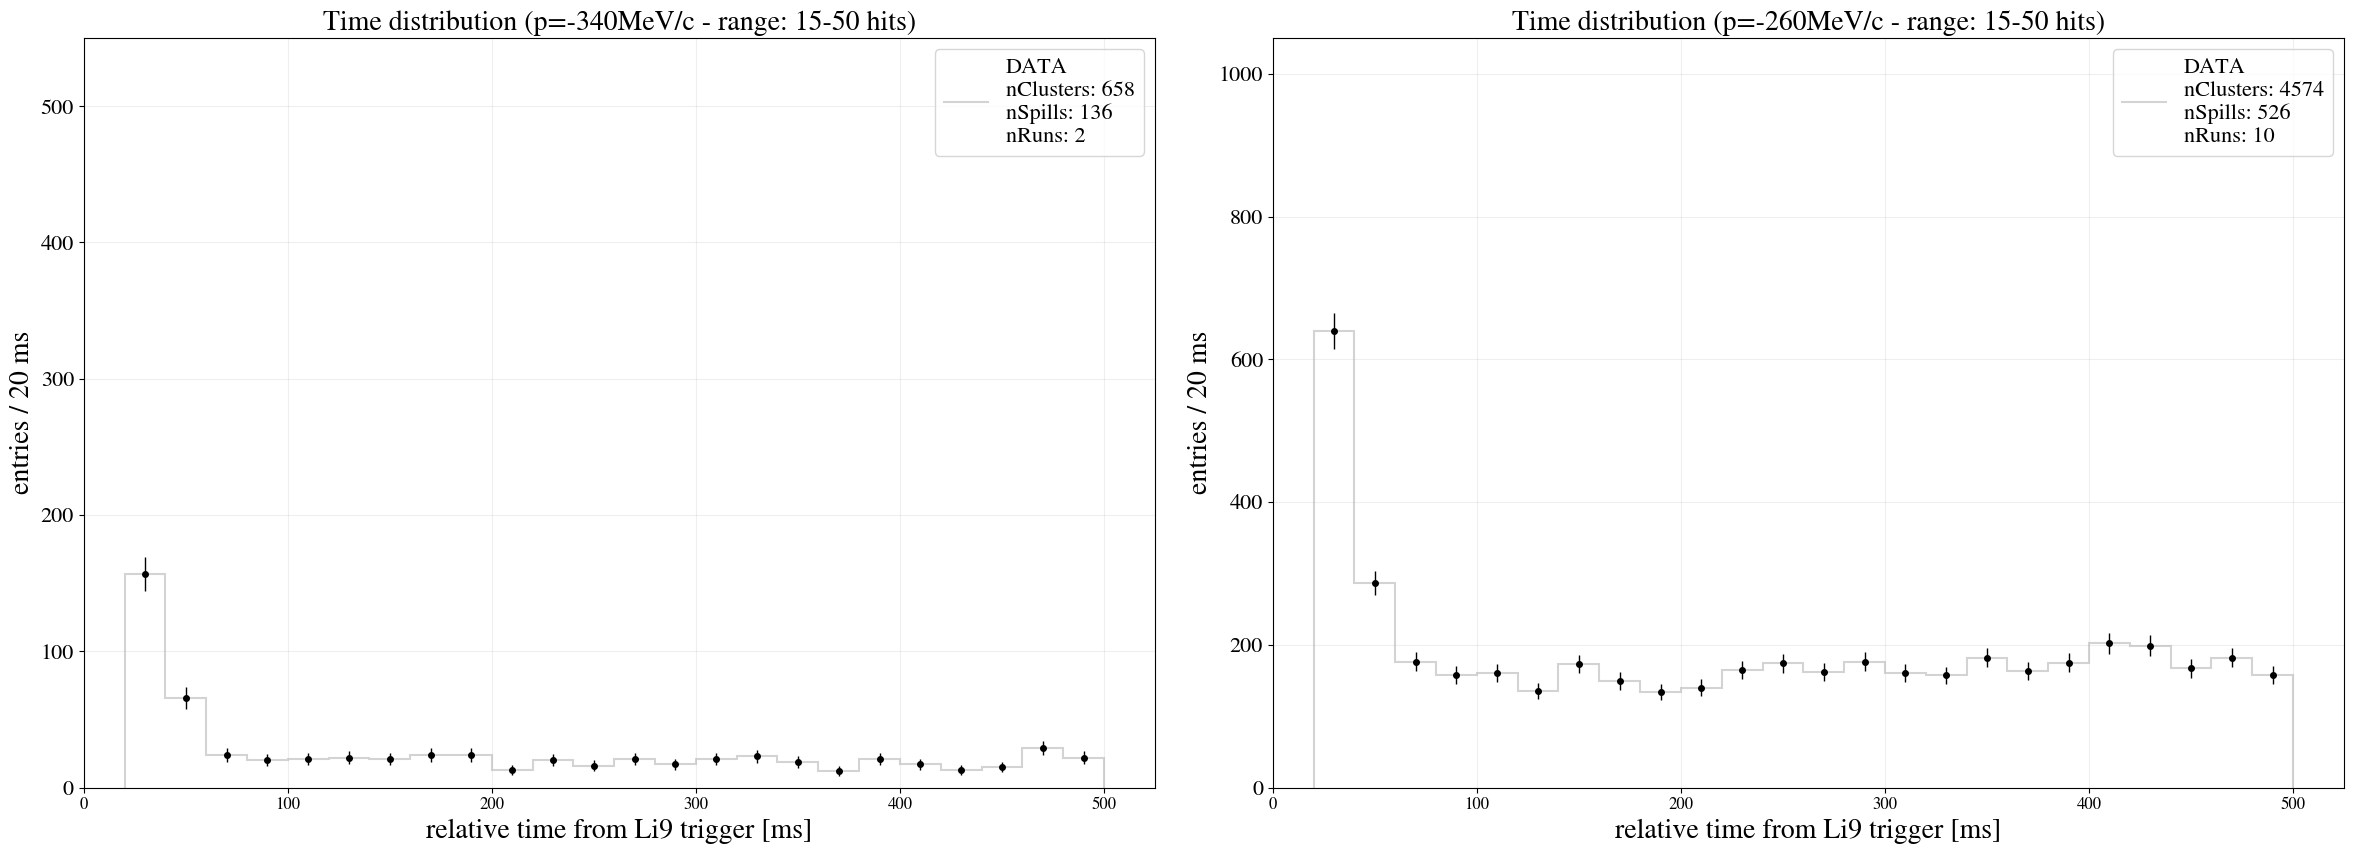

In [8]:
# ----------------------------------------------------------------------
# DATA LOADING & MERGING BY MOMENTUM
# ----------------------------------------------------------------------
momentum_map = {run: get_beam_momentum(run) for run in RUNS}

dfs_340 = []
dfs_260 = []

print("\nLoading final data files and merging by momentum...")

for run in RUNS:
    run_folder = f"{BASE_DIR}/run{run}/processed"
    final_fv_file = os.path.join(run_folder, f"Final_FV_Li9_clusters_run{run}_BKG.pkl")
    
    if os.path.exists(final_fv_file):
        try:
            df = pd.read_pickle(final_fv_file)
            if not df.empty:
                df['origin_run'] = run
                if momentum_map[run] == "-340 MeV/c":
                    dfs_340.append(df)
                else:
                    dfs_260.append(df)
        except Exception as e:
            print(f"Error loading {final_fv_file}: {e}")

df_340_combined = pd.concat(dfs_340, ignore_index=True) if dfs_340 else pd.DataFrame()
df_260_combined = pd.concat(dfs_260, ignore_index=True) if dfs_260 else pd.DataFrame()

# ----------------------------------------------------------------------
# HISTOGRAM & PLOTTING CONFIGURATION (FIXED FOR UNITS)
# ----------------------------------------------------------------------
rcParams['figure.figsize'] = [24, 9]
fig, axs = plt.subplots(1, 2, sharey=False)

bin_width = 20  # ms
bins = np.arange(20, 500 + bin_width, bin_width)
time_column = "t_window_start_rel_ns" 

plot_configs = [
    {
        "df": df_340_combined,
        "ax": axs[0],
        "title": "Time distribution (p=-340MeV/c - range: 15-50 hits)",
        "num_runs": len(dfs_340),
        "y_max": 550  # <-- Límite fijo solicitado para el subplot izquierdo
        #"const_line": 45.98  
    },
    {
        "df": df_260_combined,
        "ax": axs[1],
        "title": "Time distribution (p=-260MeV/c - range: 15-50 hits)",
        "num_runs": len(dfs_260),
        "y_max": 1050  # <-- Límite fijo solicitado para el subplot derecho
        #"const_line": 45.98  
    }
]

for config in plot_configs:
    df_plot = config["df"]
    ax = config["ax"]
    
    if df_plot.empty:
        ax.text(0.5, 0.5, "No Data Within FV", transform=ax.transAxes, ha="center")
        ax.set_title(config["title"])
        continue

    if time_column not in df_plot.columns:
        print(f"Error: Column '{time_column}' not found.")
        continue

    # UNIT CONVERSION CRITICAL FIX: Convert 't_window_start_rel_ns' from ns to ms
    time_in_ms = df_plot[time_column] / 1e6

    # Apply the exact histogram logic with the 20 ms offset shift
    counts, bin_edges = np.histogram(time_in_ms + 20, bins=bins)
    
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    errors = np.sqrt(np.maximum(counts, 1))

    # Draw step histogram profile
    ax.stairs(
        counts,
        bin_edges,
        color="lightgray",
        linewidth=1.5,
        label=(
            f"DATA\n"
            f"nClusters: {len(df_plot)}\n"
            f"nSpills: {df_plot['spill_id'].nunique() if 'spill_id' in df_plot.columns else 'N/A'}\n"
            f"nRuns: {config['num_runs']}"
        ),
    )

    # Superimpose clean error data points
    ax.errorbar(bin_centers, counts, yerr=errors, fmt="o", color="black", markersize=4, capsize=0, elinewidth=1, ls="none")

    # Horizontal baseline restriction strictly bounded between 20 ms and 500 ms
    #ax.hlines(y=config["const_line"], xmin=20, xmax=500, color="red", linewidth=2.5, label=f"C = {config['const_line']}")

    # Set axes parameters, labels, and clean background grids
    ax.set_title(config["title"])
    ax.set_xlabel("relative time from Li9 trigger [ms]")
    ax.set_ylabel(f"entries / {bin_width} ms")
    ax.grid(True, which="both", linestyle="-", alpha=0.2)
    
    # Explicitly linear scale to match the aesthetic reference panel
    ax.set_yscale("linear")
    ax.set_xlim(0, 525)
    ax.set_ylim(0, config["y_max"]) # <-- Aplicado el límite fijo sin cambiar nada más
    
    ax.legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.show()


Loading final Signal and BKG files and merging by momentum...


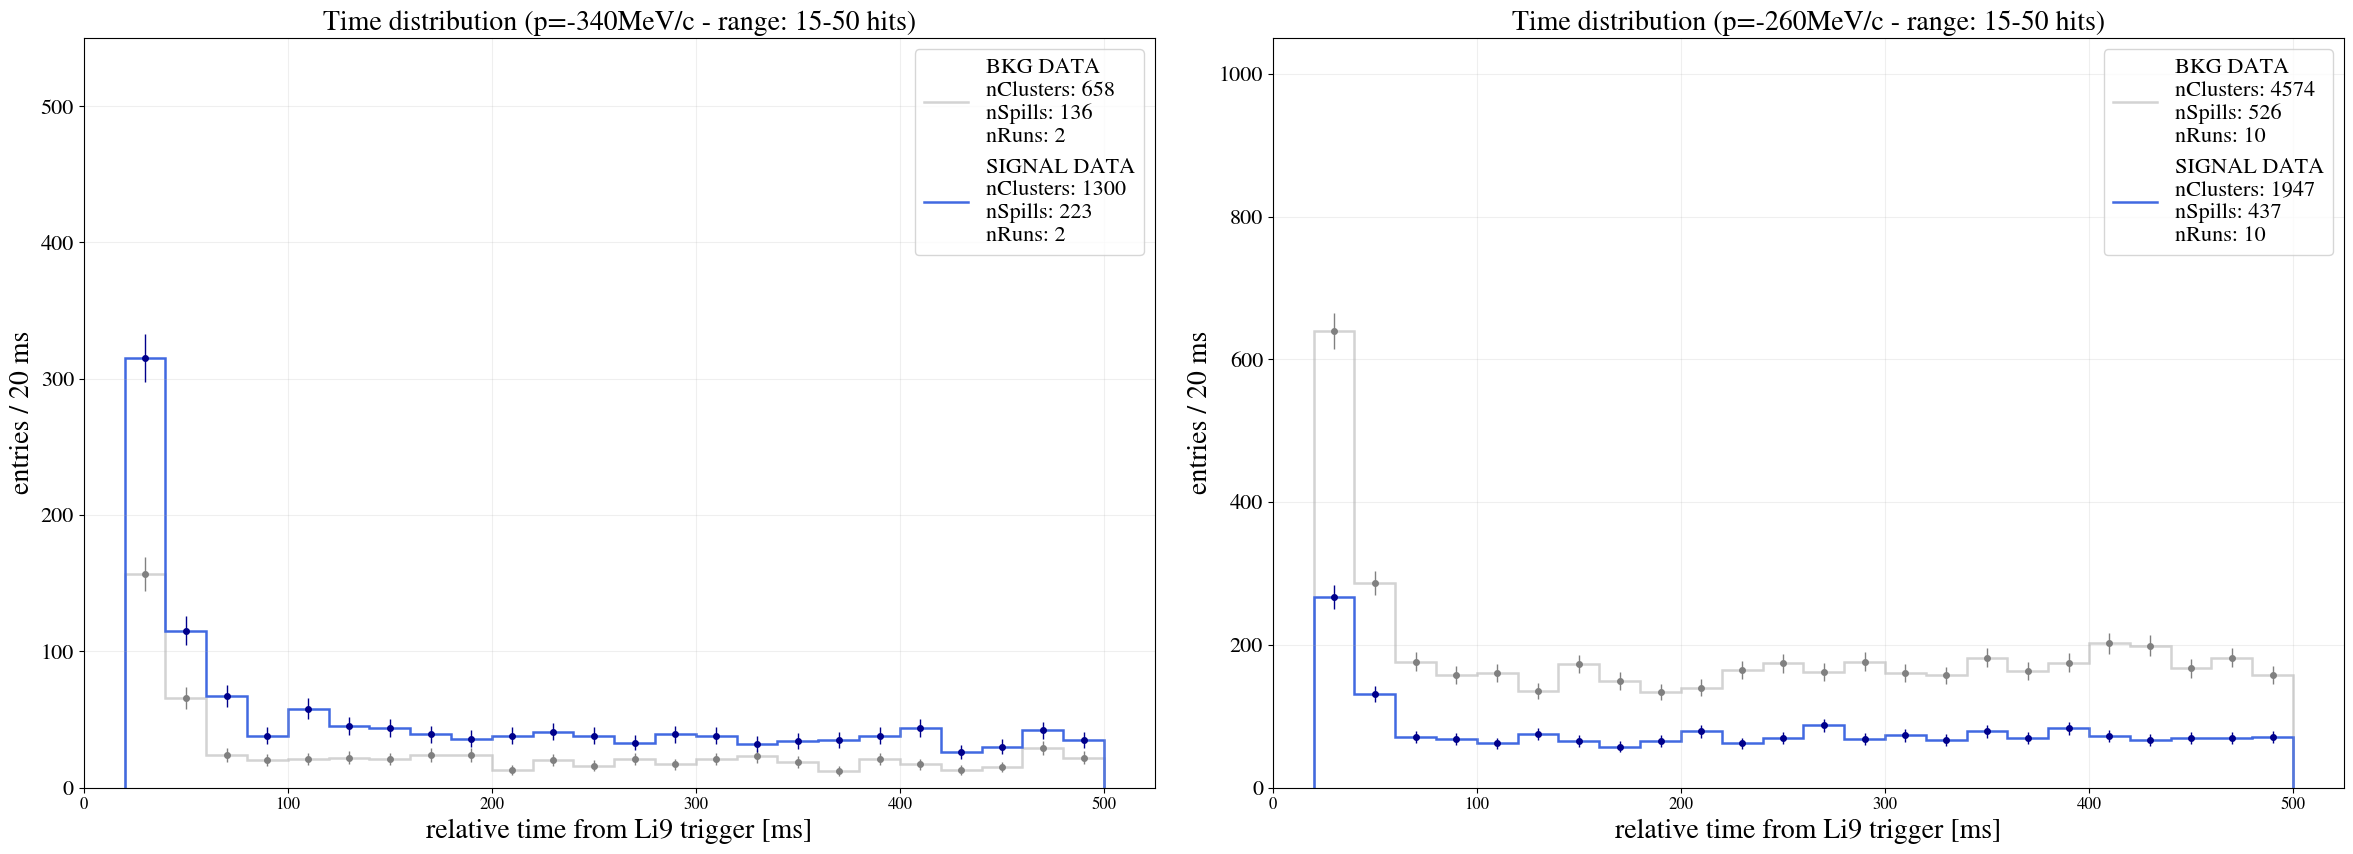

In [19]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

# ----------------------------------------------------------------------
# DATA LOADING & MERGING BY MOMENTUM (SIGNAL & BKG SUPERIMPOSED)
# ----------------------------------------------------------------------
momentum_map = {run: get_beam_momentum(run) for run in RUNS}

# Listas separadas para clasificar por momentum y por tipo de muestra
dfs_340_sig = []
dfs_340_bkg = []
dfs_260_sig = []
dfs_260_bkg = []

print("\nLoading final Signal and BKG files and merging by momentum...")

for run in RUNS:
    run_folder = f"{BASE_DIR}/run{run}/processed"
    
    # Rutas para ambos tipos de archivos .pkl procesados en tu pipeline
    sig_file = os.path.join(run_folder, f"Final_FV_Li9_clusters_run{run}.pkl")
    bkg_file = os.path.join(run_folder, f"Final_FV_Li9_clusters_run{run}_BKG.pkl")
    
    # 1. Cargar datos de SEÑAL
    if os.path.exists(sig_file):
        try:
            df_sig = pd.read_pickle(sig_file)
            if not df_sig.empty:
                df_sig['origin_run'] = run
                if momentum_map[run] == "-340 MeV/c":
                    dfs_340_sig.append(df_sig)
                else:
                    dfs_260_sig.append(df_sig)
        except Exception as e:
            print(f"Error loading Signal file {sig_file}: {e}")

    # 2. Cargar datos de BACKGROUND (BKG)
    if os.path.exists(bkg_file):
        try:
            df_bkg = pd.read_pickle(bkg_file)
            if not df_bkg.empty:
                df_bkg['origin_run'] = run
                if momentum_map[run] == "-340 MeV/c":
                    dfs_340_bkg.append(df_bkg)
                else:
                    dfs_260_bkg.append(df_bkg)
        except Exception as e:
            print(f"Error loading BKG file {bkg_file}: {e}")

# Concatenación segura de los dataframes consolidados
df_340_sig_comb = pd.concat(dfs_340_sig, ignore_index=True) if dfs_340_sig else pd.DataFrame()
df_340_bkg_comb = pd.concat(dfs_340_bkg, ignore_index=True) if dfs_340_bkg else pd.DataFrame()
df_260_sig_comb = pd.concat(dfs_260_sig, ignore_index=True) if dfs_260_sig else pd.DataFrame()
df_260_bkg_comb = pd.concat(dfs_260_bkg, ignore_index=True) if dfs_260_bkg else pd.DataFrame()


# ----------------------------------------------------------------------
# HISTOGRAM & PLOTTING CONFIGURATION (SUPERIMPOSED PLOT)
# ----------------------------------------------------------------------
rcParams['figure.figsize'] = [24, 9]
fig, axs = plt.subplots(1, 2, sharey=False)

bin_width = 20  # ms
bins = np.arange(20, 500 + bin_width, bin_width)
time_column = "t_window_start_rel_ns" 

# Estructura de configuración adaptada para manejar parejas de DataFrames en cada eje
plot_configs = [
    {
        "df_sig": df_340_sig_comb,
        "df_bkg": df_340_bkg_comb,
        "ax": axs[0],
        "title": "Time distribution (p=-340MeV/c - range: 15-50 hits)",
        "num_runs_sig": len(dfs_340_sig),
        "num_runs_bkg": len(dfs_340_bkg),
        "y_max": 550  
    },
    {
        "df_sig": df_260_sig_comb,
        "df_bkg": df_260_bkg_comb,
        "ax": axs[1],
        "title": "Time distribution (p=-260MeV/c - range: 15-50 hits)",
        "num_runs_sig": len(dfs_260_sig),
        "num_runs_bkg": len(dfs_260_bkg),
        "y_max": 1050  
    }
]

for config in plot_configs:
    ax = config["ax"]
    ax.set_title(config["title"])
    
    # --- SUB-PLOTTER: FUNCIÓN INTERNA PARA EVITAR DUPLICAR LÓGICA DE HISTOGRAMA ---
    def plot_sample(df_plot, sample_label, hist_color, marker_color, num_runs):
        if df_plot.empty or (time_column not in df_plot.columns):
            return False
            
        # Conversión de unidades de nanosegundos a milisegundos
        time_in_ms = df_plot[time_column] / 1e6

        # Lógica matemática de histograma con el desfase de +20 ms
        counts, bin_edges = np.histogram(time_in_ms + 20, bins=bins)
        
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        errors = np.sqrt(np.maximum(counts, 1))

        # Generar etiqueta descriptiva con los metadatos de la muestra
        n_spills = df_plot['spill_id'].nunique() if 'spill_id' in df_plot.columns else 'N/A'
        label_text = (
            f"{sample_label}\n"
            f"nClusters: {len(df_plot)}\n"
            f"nSpills: {n_spills}\n"
            f"nRuns: {num_runs}"
        )

        # Dibujar perfil escalonado del histograma
        ax.stairs(
            counts,
            bin_edges,
            color=hist_color,
            linewidth=1.8,
            label=label_text
        )

        # Superponer puntos de datos con barras de error limpias sin cap
        ax.errorbar(
            bin_centers, counts, yerr=errors, fmt="o", 
            color=marker_color, markersize=4, capsize=0, 
            elinewidth=1, ls="none"
        )
        return True


    
    # Dibujar Muestra 2: BACKGROUND (Azul de Control / Azul Marino)
    has_bkg = plot_sample(
        config["df_bkg"], "BKG DATA", 
        hist_color="lightgray", marker_color="gray", 
        num_runs=config["num_runs_bkg"]
    )

        # Dibujar Muestra 1: SEÑAL (Gris Claro / Negro)
    has_sig = plot_sample(
        config["df_sig"], "SIGNAL DATA", 
        hist_color="royalblue", marker_color="darkblue", 
        num_runs=config["num_runs_sig"]
    )

    # Si ninguna de las dos muestras tenía datos dentro del Volumen Fiducial
    if not has_sig and not has_bkg:
        ax.text(0.5, 0.5, "No Data Within FV (Sig or Bkg)", transform=ax.transAxes, ha="center")
        continue

    # Configuración de formato del canvas común a ambos paneles
    ax.set_xlabel("relative time from Li9 trigger [ms]")
    ax.set_ylabel(f"entries / {bin_width} ms")
    ax.grid(True, which="both", linestyle="-", alpha=0.2)
    
    ax.set_yscale("linear")
    ax.set_xlim(0, 525)
    ax.set_ylim(0, config["y_max"])
    
    ax.legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.show()

Loading final Signal and BKG files for -340 MeV/c runs...
--> Background Constante Ajustado: C = 8.65 ± 0.50


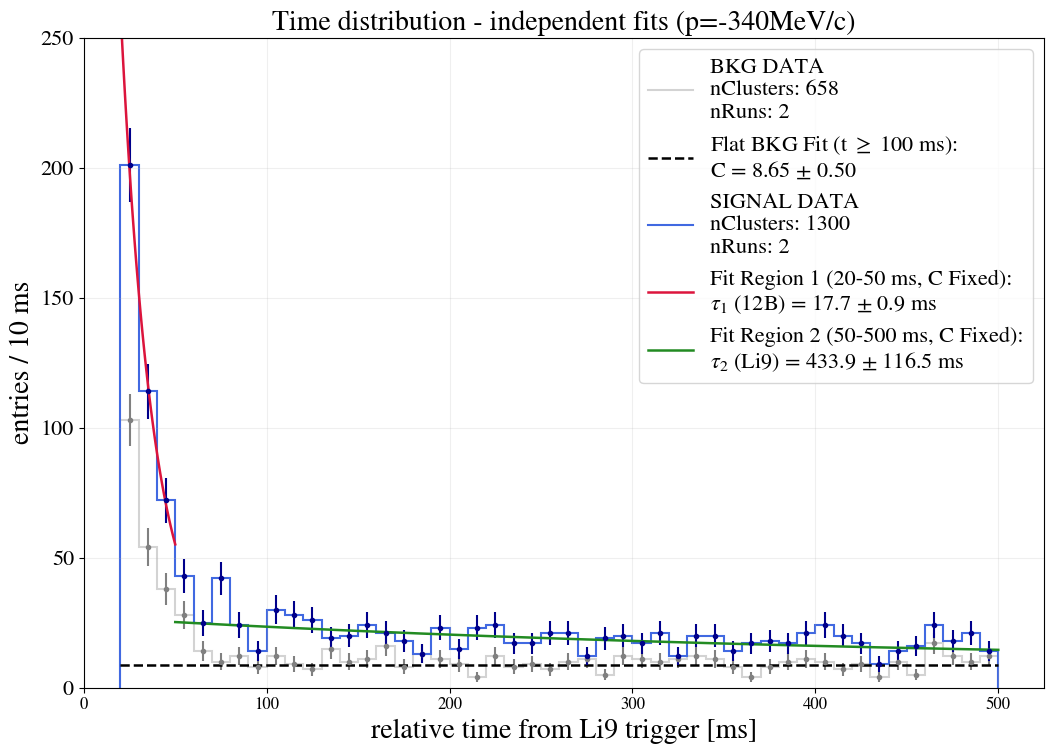

In [48]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from scipy.optimize import curve_fit

# ----------------------------------------------------------------------
# 1. CARGA DE DATOS (EXCLUSIVO -340 MeV/c: RUNS 1846 Y 1848)
# ----------------------------------------------------------------------
RUNS_340 = [1846, 1848]
dfs_340_sig = []
dfs_340_bkg = []

print("Loading final Signal and BKG files for -340 MeV/c runs...")

for run in RUNS_340:
    run_folder = f"{BASE_DIR}/run{run}/processed"
    sig_file = os.path.join(run_folder, f"Final_FV_Li9_clusters_run{run}.pkl")
    bkg_file = os.path.join(run_folder, f"Final_FV_Li9_clusters_run{run}_BKG.pkl")
    
    if os.path.exists(sig_file):
        df_sig = pd.read_pickle(sig_file)
        if not df_sig.empty:
            df_sig['origin_run'] = run
            dfs_340_sig.append(df_sig)
            
    if os.path.exists(bkg_file):
        df_bkg = pd.read_pickle(bkg_file)
        if not df_bkg.empty:
            df_bkg['origin_run'] = run
            dfs_340_bkg.append(df_bkg)

df_sig_total = pd.concat(dfs_340_sig, ignore_index=True) if dfs_340_sig else pd.DataFrame()
df_bkg_total = pd.concat(dfs_340_bkg, ignore_index=True) if dfs_340_bkg else pd.DataFrame()

# ----------------------------------------------------------------------
# 2. CONFIGURACIÓN DEL HISTOGRAMA CON RESOLUCIÓN DE 10 ms
# ----------------------------------------------------------------------
bin_width = 10  
bins = np.arange(20, 500 + bin_width, bin_width)
time_column = "t_window_start_rel_ns"

# Extraer tiempos en ms aplicando el offset de +20 ms
times_sig_ms = (df_sig_total[time_column] / 1e6) + 20
times_bkg_ms = (df_bkg_total[time_column] / 1e6) + 20

# Calcular contenidos de los histogramas
counts_sig, bin_edges = np.histogram(times_sig_ms, bins=bins)
counts_bkg, _ = np.histogram(times_bkg_ms, bins=bins)

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
errors_sig = np.sqrt(np.maximum(counts_sig, 1))
errors_bkg = np.sqrt(np.maximum(counts_bkg, 1))

# ----------------------------------------------------------------------
# 3. FIT 1: BACKGROUND PLANO (C) - EXCLUYENDO PRIMEROS BINS (t < 100 ms)
# ----------------------------------------------------------------------
t_cut_bkg = 100  # ms
mask_bkg_fit = bin_centers >= t_cut_bkg

def flat_func(t, c):
    return np.full_like(t, c)

popt_bkg, pcov_bkg = curve_fit(
    flat_func, 
    bin_centers[mask_bkg_fit], 
    counts_bkg[mask_bkg_fit], 
    sigma=errors_bkg[mask_bkg_fit],
    p0=[np.mean(counts_bkg[mask_bkg_fit])]
)
C_const = popt_bkg[0]
C_err = np.sqrt(pcov_bkg[0, 0])
print(f"--> Background Constante Ajustado: C = {C_const:.2f} ± {C_err:.2f}")

# ----------------------------------------------------------------------
# 4. CURVE FITS INDEPENDIENTES CON C FIJA EN AMBAS REGIONES
# ----------------------------------------------------------------------
def exp_with_c(t, Amplitude, tau):
    return Amplitude * np.exp(-t / tau) + C_const

# --- REGION 1: 20 a 50 ms (Decaimiento para 12B) ---
mask_r1 = (bin_centers >= 20) & (bin_centers <= 50)

popt_r1, pcov_r1 = curve_fit(
    exp_with_c,
    bin_centers[mask_r1],
    counts_sig[mask_r1],
    sigma=errors_sig[mask_r1],
    p0=[400.0, 20.0],
    bounds=([0, 2], [5000, 200])
)
A_fit, tau1_fit = popt_r1
tau1_err = np.sqrt(pcov_r1[1, 1])

# --- REGION 2: 50 a 500 ms (Decaimiento para Li9) ---
mask_r2 = bin_centers >= 50

popt_r2, pcov_r2 = curve_fit(
    exp_with_c,
    bin_centers[mask_r2],
    counts_sig[mask_r2],
    sigma=errors_sig[mask_r2],
    p0=[100.0, 170.0],
    bounds=([0, 30], [1000, 3000])
)
B_fit, tau2_fit = popt_r2
tau2_err = np.sqrt(pcov_r2[1, 1])

# ----------------------------------------------------------------------
# 5. GRÁFICO FINAL SUPERPUESTO CON AMBOS AJUSTES ACOOTADOS
# ----------------------------------------------------------------------
rcParams['figure.figsize'] = [11, 8]
fig, ax = plt.subplots()

# A. Dibujar Muestra de Background (Gris)
ax.stairs(counts_bkg, bin_edges, color="lightgray", linewidth=1.5, 
          label=f"BKG DATA\nnClusters: {len(df_bkg_total)}\nnRuns: {len(RUNS_340)}")
ax.errorbar(bin_centers, counts_bkg, yerr=errors_bkg, fmt="o", color="gray", markersize=3, capsize=0, ls="none")

# B. Dibujar Línea de la Constante de Fondo
t_plot_bkg = np.linspace(20, 500, 1000)
ax.plot(t_plot_bkg, flat_func(t_plot_bkg, C_const), color="black", linestyle="--", linewidth=1.8,
        label=f"Flat BKG Fit (t $\geq$ {t_cut_bkg} ms):\nC = {C_const:.2f} $\pm$ {C_err:.2f}")

# C. Dibujar Muestra de Señal (Azul)
ax.stairs(counts_sig, bin_edges, color="royalblue", linewidth=1.5, 
          label=f"SIGNAL DATA\nnClusters: {len(df_sig_total)}\nnRuns: {len(RUNS_340)}")
ax.errorbar(bin_centers, counts_sig, yerr=errors_sig, fmt="o", color="darkblue", markersize=3, capsize=0, ls="none")

# D. Dibujar Curva Región 1 (20-50 ms) -> Crimson continua
t_plot_r1 = np.linspace(20, 50, 100)
ax.plot(t_plot_r1, exp_with_c(t_plot_r1, *popt_r1), color="crimson", linewidth=1.8,
        label=f"Fit Region 1 (20-50 ms, C Fixed):\n$\\tau_1$ (12B) = {tau1_fit:.1f} $\pm$ {tau1_err:.1f} ms")

# E. CAMBIO SOLICITADO: Dibujar Curva Región 2 acotada estrictamente de 50 a 500 ms
t_plot_r2 = np.linspace(50, 500, 1000)
ax.plot(t_plot_r2, exp_with_c(t_plot_r2, *popt_r2), color="forestgreen", linewidth=1.8,
        label=f"Fit Region 2 (50-500 ms, C Fixed):\n$\\tau_2$ (Li9) = {tau2_fit:.1f} $\pm$ {tau2_err:.1f} ms")

# Formato y Estética del Lienzo
ax.set_title("Time distribution - independent fits (p=-340MeV/c)")
ax.set_xlabel("relative time from Li9 trigger [ms]")
ax.set_ylabel(f"entries / {bin_width} ms")
ax.set_xlim(0, 525)

# CAMBIO SOLICITADO: Límite del eje Y fijado exactamente en 300
ax.set_ylim(0, 250) 

ax.grid(True, which="both", linestyle="-", alpha=0.2)
ax.legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.show()

Loading final Signal and BKG files for -340 MeV/c runs...
--> Background Constante Ajustado (Fijo para el Fit Global): C = 8.65 ± 0.50

=== RESULTADOS DEL FIT GLOBAL ===
12B -> Amplitud A = 1026.3 ± 232.3 | tau_1 = 14.4 ± 1.5 ms
Li9 -> Amplitud B = 13.7 ± 2.6 | tau_2 = 750.8 ± 367.2 ms


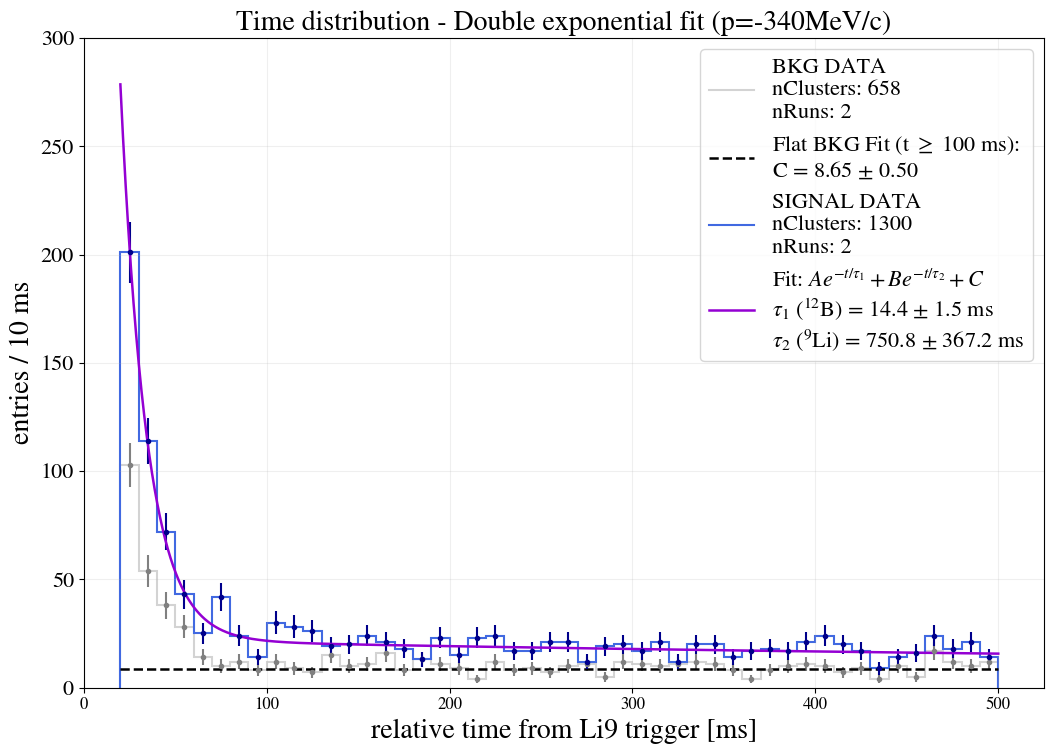

In [51]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from scipy.optimize import curve_fit

# ----------------------------------------------------------------------
# 1. CARGA DE DATOS (EXCLUSIVO -340 MeV/c: RUNS 1846 Y 1848)
# ----------------------------------------------------------------------
RUNS_340 = [1846, 1848]
dfs_340_sig = []
dfs_340_bkg = []

print("Loading final Signal and BKG files for -340 MeV/c runs...")

for run in RUNS_340:
    run_folder = f"{BASE_DIR}/run{run}/processed"
    sig_file = os.path.join(run_folder, f"Final_FV_Li9_clusters_run{run}.pkl")
    bkg_file = os.path.join(run_folder, f"Final_FV_Li9_clusters_run{run}_BKG.pkl")
    
    if os.path.exists(sig_file):
        df_sig = pd.read_pickle(sig_file)
        if not df_sig.empty:
            df_sig['origin_run'] = run
            dfs_340_sig.append(df_sig)
            
    if os.path.exists(bkg_file):
        df_bkg = pd.read_pickle(bkg_file)
        if not df_bkg.empty:
            df_bkg['origin_run'] = run
            dfs_340_bkg.append(df_bkg)

df_sig_total = pd.concat(dfs_340_sig, ignore_index=True) if dfs_340_sig else pd.DataFrame()
df_bkg_total = pd.concat(dfs_340_bkg, ignore_index=True) if dfs_340_bkg else pd.DataFrame()

# ----------------------------------------------------------------------
# 2. CONFIGURACIÓN DEL HISTOGRAMA CON RESOLUCIÓN DE 10 ms
# ----------------------------------------------------------------------
bin_width = 10  
bins = np.arange(20, 500 + bin_width, bin_width)
time_column = "t_window_start_rel_ns"

# Extraer tiempos en ms aplicando el offset de +20 ms
times_sig_ms = (df_sig_total[time_column] / 1e6) + 20
times_bkg_ms = (df_bkg_total[time_column] / 1e6) + 20

# Calcular contenidos de los histogramas
counts_sig, bin_edges = np.histogram(times_sig_ms, bins=bins)
counts_bkg, _ = np.histogram(times_bkg_ms, bins=bins)

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
errors_sig = np.sqrt(np.maximum(counts_sig, 1))
errors_bkg = np.sqrt(np.maximum(counts_bkg, 1))

# ----------------------------------------------------------------------
# 3. FIT 1: BACKGROUND PLANO (C) - EXCLUYENDO PRIMEROS BINS (t < 100 ms)
# ----------------------------------------------------------------------
t_cut_bkg = 100  # ms
mask_bkg_fit = bin_centers >= t_cut_bkg

def flat_func(t, c):
    return np.full_like(t, c)

popt_bkg, pcov_bkg = curve_fit(
    flat_func, 
    bin_centers[mask_bkg_fit], 
    counts_bkg[mask_bkg_fit], 
    sigma=errors_bkg[mask_bkg_fit],
    p0=[np.mean(counts_bkg[mask_bkg_fit])]
)
C_const = popt_bkg[0]
C_err = np.sqrt(pcov_bkg[0, 0])
print(f"--> Background Constante Ajustado (Fijo para el Fit Global): C = {C_const:.2f} ± {C_err:.2f}")

# ----------------------------------------------------------------------
# 4. FIT GLOBAL COMBINADO (12B + Li9 + C fija) EN TODO EL RANGO
# ----------------------------------------------------------------------

# Expresión de la doble exponencial con el parámetro C inyectado estático
def double_exp_with_c(t, A, tau1, B, tau2):
    return A * np.exp(-t / tau1) + B * np.exp(-t / tau2) + C_const

# La máscara ahora abarca absolutamente todos los bines disponibles desde 20 a 500 ms
mask_global = (bin_centers >= 20) & (bin_centers <= 500)

# Semillas iniciales y límites para los 4 parámetros libres (A, tau1, B, tau2)
# p0 = [A, tau1, B, tau2]
p0_global = [400.0, 20.0, 100.0, 170.0]
bounds_global = (
    [0, 2, 0, 30],         # Límites inferiores
    [5000, 200, 1000, 3000] # Límites superiores
)

popt_g, pcov_g = curve_fit(
    double_exp_with_c,
    bin_centers[mask_global],
    counts_sig[mask_global],
    sigma=errors_sig[mask_global],
    p0=p0_global,
    bounds=bounds_global
)

# Extracción de parámetros y sus errores asociados (raíz de la diagonal de la covarianza)
A_fit, tau1_fit, B_fit, tau2_fit = popt_g
A_err, tau1_err, B_err, tau2_err = np.sqrt(np.diag(pcov_g))

print(f"\n=== RESULTADOS DEL FIT GLOBAL ===")
print(f"12B -> Amplitud A = {A_fit:.1f} ± {A_err:.1f} | tau_1 = {tau1_fit:.1f} ± {tau1_err:.1f} ms")
print(f"Li9 -> Amplitud B = {B_fit:.1f} ± {B_err:.1f} | tau_2 = {tau2_fit:.1f} ± {tau2_err:.1f} ms")

# ----------------------------------------------------------------------
# 5. GRÁFICO FINAL CON LA CURVA COMBINADA GLOBAL
# ----------------------------------------------------------------------
rcParams['figure.figsize'] = [11, 8]
fig, ax = plt.subplots()

# A. Dibujar Muestra de Background (Gris)
ax.stairs(counts_bkg, bin_edges, color="lightgray", linewidth=1.5, 
          label=f"BKG DATA\nnClusters: {len(df_bkg_total)}\nnRuns: {len(RUNS_340)}")
ax.errorbar(bin_centers, counts_bkg, yerr=errors_bkg, fmt="o", color="gray", markersize=3, capsize=0, ls="none")

# B. Dibujar Línea de la Constante de Fondo
t_plot_bkg = np.linspace(20, 500, 1000)
ax.plot(t_plot_bkg, flat_func(t_plot_bkg, C_const), color="black", linestyle="--", linewidth=1.8,
        label=f"Flat BKG Fit (t $\geq$ {t_cut_bkg} ms):\nC = {C_const:.2f} $\pm$ {C_err:.2f}")

# C. Dibujar Muestra de Señal (Azul)
ax.stairs(counts_sig, bin_edges, color="royalblue", linewidth=1.5, 
          label=f"SIGNAL DATA\nnClusters: {len(df_sig_total)}\nnRuns: {len(RUNS_340)}")
ax.errorbar(bin_centers, counts_sig, yerr=errors_sig, fmt="o", color="darkblue", markersize=3, capsize=0, ls="none")


# D. Dibujar la Curva Única del Fit Global (Doble Exponencial)
t_plot_global = np.linspace(20, 500, 1000)
label_fit = (
    f"Fit: $A e^{{-t/\\tau_1}} + B e^{{-t/\\tau_2}} + C$\n"
    f"$\\tau_1$ ($^{{12}}$B) = {tau1_fit:.1f} $\pm$ {tau1_err:.1f} ms\n"
    f"$\\tau_2$ ($^{9}$Li) = {tau2_fit:.1f} $\pm$ {tau2_err:.1f} ms"
)
ax.plot(t_plot_global, double_exp_with_c(t_plot_global, *popt_g), color="darkviolet", linewidth=1.8, label=label_fit)


# Formato y Estética del Lienzo
ax.set_title("Time distribution - Double exponential fit (p=-340MeV/c)")
ax.set_xlabel("relative time from Li9 trigger [ms]")
ax.set_ylabel(f"entries / {bin_width} ms")
ax.set_xlim(0, 525)
ax.set_ylim(0, 300) # Mantengo tu límite superior a 300 para limpieza visual

ax.grid(True, which="both", linestyle="-", alpha=0.2)
ax.legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.show()


Loading final data files and merging by momentum...

--- Calculating Fits for -340 MeV/c ---
Boro-12 Fit -> A1: 576.02, tau_1: 23.08 +/- 5.06 ms, C1: 0.00
Litio-9 Fit -> A2: 24.60, tau_2: 100.00 +/- 63.69 ms, C2: 16.51

--- Calculating Fits for -260 MeV/c ---
Boro-12 Fit -> A1: 2199.85, tau_1: 23.74 +/- 2.86 ms, C1: 18.18
Litio-9 Fit -> A2: 32.90, tau_2: 100.00 +/- 127.60 ms, C2: 162.52


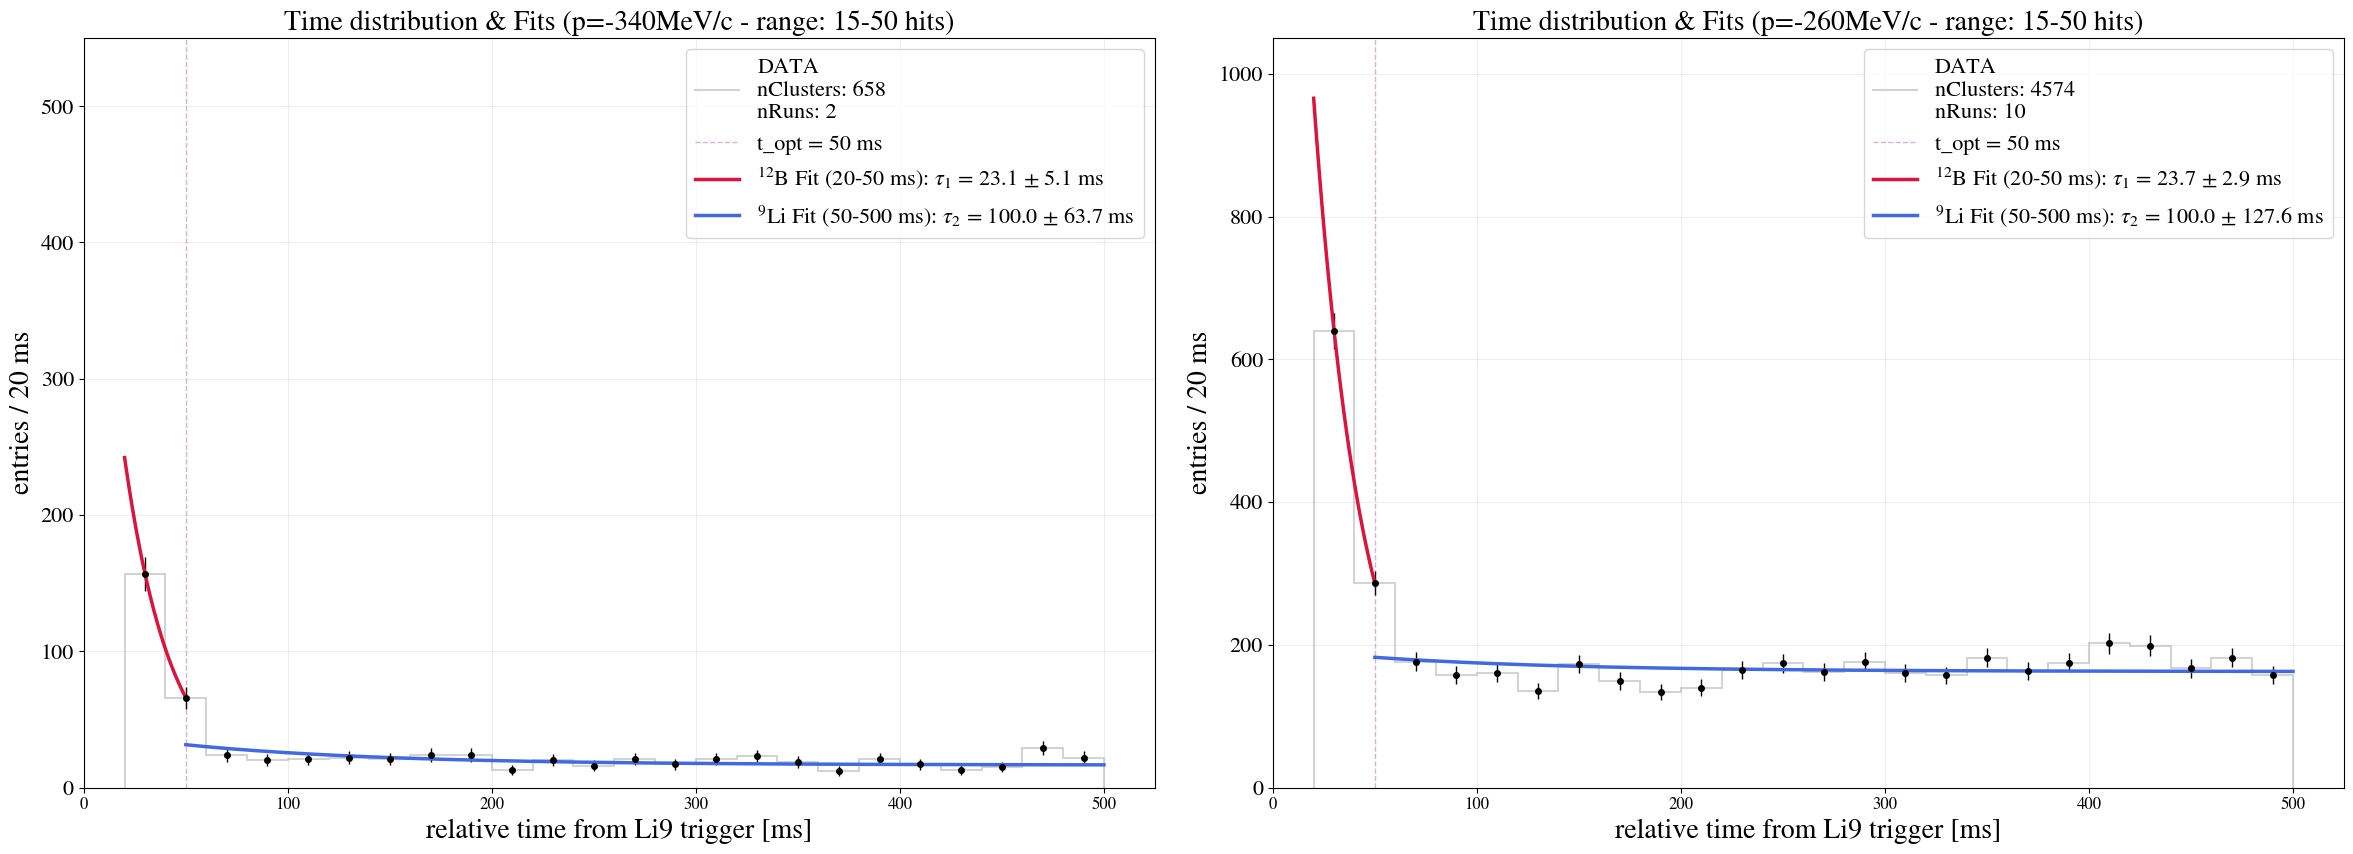

In [9]:
# ----------------------------------------------------------------------
# DEFINICIÓN DE MODELOS DE AJUSTE (CON CONSTANTE DE FONDO ACCIDENTAL)
# ----------------------------------------------------------------------
# Esperamos tau_1 (~29.1 ms para B12) y tau_2 (~257.2 ms para Li9)
def boro_model(t, A1, tau_1, C1):
    return A1 * np.exp(-t / tau_1) + C1

def li9_model(t, A2, tau_2, C2):
    return A2 * np.exp(-t / tau_2) + C2

# ----------------------------------------------------------------------
# DATA LOADING & MERGING BY MOMENTUM
# ----------------------------------------------------------------------
momentum_map = {run: get_beam_momentum(run) for run in RUNS}

dfs_340 = []
dfs_260 = []

print("\nLoading final data files and merging by momentum...")

for run in RUNS:
    run_folder = f"{BASE_DIR}/run{run}/processed"
    final_fv_file = os.path.join(run_folder, f"Final_FV_Li9_clusters_run{run}_BKG.pkl")
    
    if os.path.exists(final_fv_file):
        try:
            df = pd.read_pickle(final_fv_file)
            if not df.empty:
                df['origin_run'] = run
                if momentum_map[run] == "-340 MeV/c":
                    dfs_340.append(df)
                else:
                    dfs_260.append(df)
        except Exception as e:
            print(f"Error loading {final_fv_file}: {e}")

df_340_combined = pd.concat(dfs_340, ignore_index=True) if dfs_340 else pd.DataFrame()
df_260_combined = pd.concat(dfs_260, ignore_index=True) if dfs_260 else pd.DataFrame()

# ----------------------------------------------------------------------
# HISTOGRAM & PLOTTING CONFIGURATION
# ----------------------------------------------------------------------
rcParams['figure.figsize'] = [24, 9]
fig, axs = plt.subplots(1, 2, sharey=False)

bin_width = 20  # ms
bins = np.arange(20, 500 + bin_width, bin_width)
time_column = "t_window_start_rel_ns" 

plot_configs = [
    {
        "df": df_340_combined,
        "ax": axs[0],
        "title": "Time distribution & Fits (p=-340MeV/c - range: 15-50 hits)",
        "num_runs": len(dfs_340),
        "y_max": 550,
        "name": "-340 MeV/c"
    },
    {
        "df": df_260_combined,
        "ax": axs[1],
        "title": "Time distribution & Fits (p=-260MeV/c - range: 15-50 hits)",
        "num_runs": len(dfs_260),
        "y_max": 1050,
        "name": "-260 MeV/c"
    }
]

for config in plot_configs:
    df_plot = config["df"]
    ax = config["ax"]
    
    if df_plot.empty:
        ax.text(0.5, 0.5, "No Data Within FV", transform=ax.transAxes, ha="center")
        ax.set_title(config["title"])
        continue

    if time_column not in df_plot.columns:
        print(f"Error: Column '{time_column}' not found.")
        continue

    # Conversión crítica de unidades: ns a ms
    time_in_ms = df_plot[time_column] / 1e6
    time_shifted = time_in_ms + 20

    # Generar histograma primario
    counts, bin_edges = np.histogram(time_shifted, bins=bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    errors = np.sqrt(np.maximum(counts, 1))

    # Pintar histograma de datos
    ax.stairs(
        counts,
        bin_edges,
        color="lightgray",
        linewidth=1.5,
        label=(
            f"DATA\n"
            f"nClusters: {len(df_plot)}\n"
            f"nRuns: {config['num_runs']}"
        ),
    )
    ax.errorbar(bin_centers, counts, yerr=errors, fmt="o", color="black", markersize=4, capsize=0, elinewidth=1, ls="none")

    # Línea vertical discontinua violeta para marcar la separación de regiones
    ax.axvline(x=50, color="purple", alpha=0.3, linestyle="--", linewidth=1, label=r"t_opt = 50 ms")

    # ------------------------------------------------------------------
    # FITTING LOGIC BY TIME WINDOWS
    # ------------------------------------------------------------------
    print(f"\n--- Calculating Fits for {config['name']} ---")
    
    # Tramo 1: Boro-12 (20 ms a 50 ms)
    mask_boro = (bin_centers >= 20) & (bin_centers <= 50)
    t_boro = bin_centers[mask_boro]
    n_boro = counts[mask_boro]
    err_boro = errors[mask_boro]
    
    p0_boro = [max(n_boro), 30.0, min(n_boro)]
    bounds_boro = ([0, 5, 0], [np.inf, 100, np.inf])
    
    try:
        popt_boro, pcov_boro = curve_fit(boro_model, t_boro, n_boro, p0=p0_boro, bounds=bounds_boro, sigma=err_boro, absolute_sigma=True)
        perr_boro = np.sqrt(np.diagonal(pcov_boro))
        
        t_fit_boro = np.linspace(20, 50, 100)
        ax.plot(t_fit_boro, boro_model(t_fit_boro, *popt_boro), color="crimson", linewidth=2.5, 
                label=r"$^{12}$B Fit (20-50 ms): $\tau_1$ = " f"{popt_boro[1]:.1f} ± {perr_boro[1]:.1f} ms")
        print(f"Boro-12 Fit -> A1: {popt_boro[0]:.2f}, tau_1: {popt_boro[1]:.2f} +/- {perr_boro[1]:.2f} ms, C1: {popt_boro[2]:.2f}")
    except Exception as fit_error:
        print(f"Boro-12 Fit failed: {fit_error}")

    # Tramo 2: Litio-9 (50 ms a 500 ms)
    mask_li9 = (bin_centers >= 50) & (bin_centers <= 500)
    t_li9 = bin_centers[mask_li9]
    n_li9 = counts[mask_li9]
    err_li9 = errors[mask_li9]
    
    p0_li9 = [max(n_li9), 250.0, min(n_li9)]
    bounds_li9 = ([0, 100, 0], [np.inf, 600, np.inf])
    
    try:
        popt_li9, pcov_li9 = curve_fit(li9_model, t_li9, n_li9, p0=p0_li9, bounds=bounds_li9, sigma=err_li9, absolute_sigma=True)
        perr_li9 = np.sqrt(np.diagonal(pcov_li9))
        
        t_fit_li9 = np.linspace(50, 500, 200)
        ax.plot(t_fit_li9, li9_model(t_fit_li9, *popt_li9), color="royalblue", linewidth=2.5, 
                label=r"$^{9}$Li Fit (50-500 ms): $\tau_2$ = " f"{popt_li9[1]:.1f} ± {perr_li9[1]:.1f} ms")
        print(f"Litio-9 Fit -> A2: {popt_li9[0]:.2f}, tau_2: {popt_li9[1]:.2f} +/- {perr_li9[1]:.2f} ms, C2: {popt_li9[2]:.2f}")
    except Exception as fit_error:
        print(f"Litio-9 Fit failed: {fit_error}")

    # Estética y límites estrictos solicitados
    ax.set_title(config["title"])
    ax.set_xlabel("relative time from Li9 trigger [ms]")
    ax.set_ylabel(f"entries / {bin_width} ms")
    ax.grid(True, which="both", linestyle="-", alpha=0.2)
    
    ax.set_yscale("linear")
    ax.set_xlim(0, 525)
    ax.set_ylim(0, config["y_max"])
    
    ax.legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.show()

In [12]:
# ----------------------------------------------------------------------
# CALCULATION OF OBSERVED EVENTS PER RUN (TIME WINDOW SPLIT)
# ----------------------------------------------------------------------
observed_summary = []

# Combine both momentum dataframes into a single list to iterate run-by-run
# This ensures we handle all 12 target runs dynamically
all_final_dfs = dfs_340 + dfs_260

print("Calculating observed events per time window across runs...\n")

for df_run in all_final_dfs:
    if df_run.empty:
        continue
        
    # Extract the run number we tagged earlier in the data loading loop
    run_id = df_run['origin_run'].iloc[0]
    momentum = get_beam_momentum(run_id)
    
    # 1. Total absolute cluster count for this run (Post-FV and all selection cuts)
    total_final_clusters = len(df_run)
    
    # 2. Convert time to milliseconds to align with physical analysis windows
    time_ms_corrected = (df_run["t_window_start_rel_ns"] / 1e6) + 20
    
    # 3. Count events in the Signal Window [20, 50] ms
    obs_20_50 = ((time_ms_corrected >= 20) & (time_ms_corrected <= 50)).sum()
    
    # 4. Count events in the Background Window (50, 500] ms
    obs_50_500 = ((time_ms_corrected > 50) & (time_ms_corrected <= 500)).sum()
    
    # Append the row dictionary
    observed_summary.append({
        "Run Number": f"Run {run_id}",
        "Beam p [MeV/c]": momentum,
        "Total final clusters": total_final_clusters,
        "Events obs (20-50ms)": obs_20_50,
        "Events obs (50-500ms)": obs_50_500
    })

# ----------------------------------------------------------------------
# CONVERT TO DATAFRAME AND PRINT OBSERVED SUMMARY TABLE
# ----------------------------------------------------------------------
df_observed_table = pd.DataFrame(observed_summary)

# Optional: Sort rows by run number so it displays chronologically
df_observed_table = df_observed_table.sort_values(by="Run Number").reset_index(drop=True)

print("=" * 95)
print("                          BACKGROUNDFINAL OBSERVED SUMMARY TABLE")
print("=" * 95)
print(df_observed_table.to_string(index=False))
print("=" * 95)

Calculating observed events per time window across runs...

                          BACKGROUNDFINAL OBSERVED SUMMARY TABLE
Run Number Beam p [MeV/c]  Total final clusters  Events obs (20-50ms)  Events obs (50-500ms)
  Run 1846     -340 MeV/c                   362                   107                    255
  Run 1848     -340 MeV/c                   296                    88                    208
  Run 1928     -260 MeV/c                   387                    45                    342
  Run 1930     -260 MeV/c                   819                   201                    618
  Run 1932     -260 MeV/c                   747                   214                    533
  Run 1934     -260 MeV/c                   390                    74                    316
  Run 1935     -260 MeV/c                   402                    60                    342
  Run 1936     -260 MeV/c                   256                    19                    237
  Run 1937     -260 MeV/c             